# Task 1: ML Classification Project
**Alfido Tech: Artificial Intelligence Internship**

**Author:** Ezaz Ahamad | **Candidate ID:** BS/REG/127948

**Goal:** Build and evaluate a supervised classification model that predicts whether a breast tumour is **malignant** or **benign** from cell-nucleus measurements.

**Dataset:** Breast Cancer Wisconsin (Diagnostic), bundled with scikit-learn (569 samples, 30 numeric features), so no download is needed.

**Pipeline:** EDA -> preprocessing -> stratified train/test split -> 5-fold cross-validation -> compare 3 algorithms -> hyper-parameter tuning -> final evaluation (accuracy, precision, recall, F1, ROC-AUC).

In [1]:
import os
os.makedirs("images", exist_ok=True)   # folder for saved plots

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, classification_report)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## 1. Load the data

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
# In scikit-learn: target 0 = malignant, 1 = benign
df["diagnosis"] = df["target"].map({0: "malignant", 1: "benign"})

print("Shape:", df.shape)
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
df.head()

Shape: (569, 32)
Missing values: 0
Duplicate rows: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


## 2. Exploratory data analysis

diagnosis
benign       0.627
malignant    0.373
Name: proportion, dtype: float64


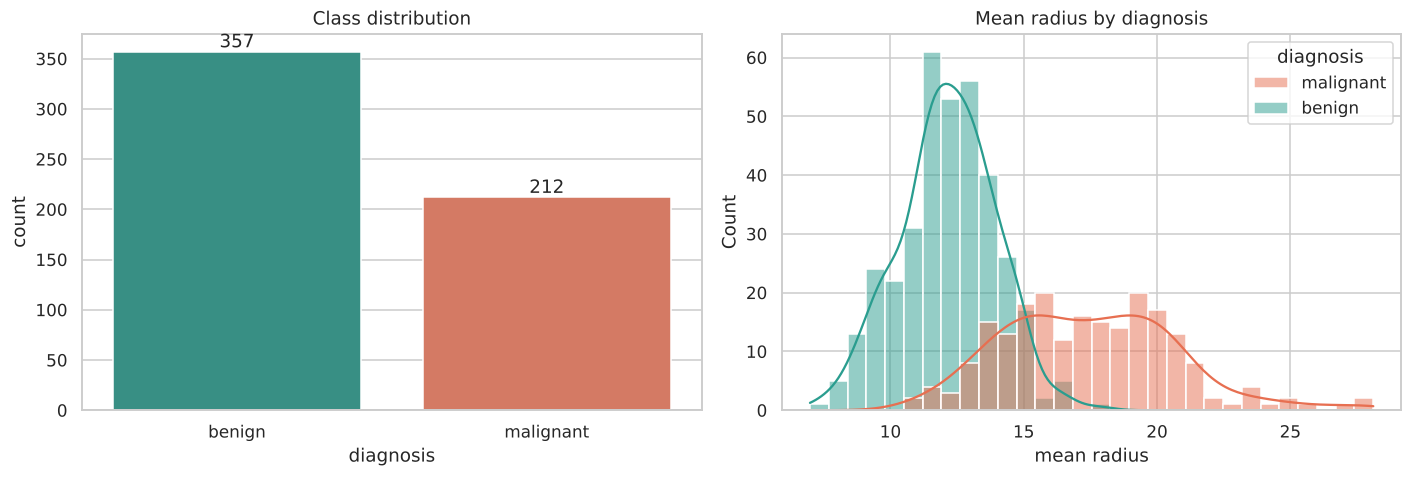

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(data=df, x="diagnosis", order=["benign", "malignant"], palette=["#2a9d8f", "#e76f51"], ax=axes[0])
axes[0].set_title("Class distribution")
for p in axes[0].patches:
    axes[0].annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom")

sns.histplot(data=df, x="mean radius", hue="diagnosis", bins=30, kde=True,
             palette={"benign": "#2a9d8f", "malignant": "#e76f51"}, ax=axes[1])
axes[1].set_title("Mean radius by diagnosis")

plt.tight_layout()
plt.savefig("images/01_class_distribution.png", dpi=130)
plt.show()

print(df["diagnosis"].value_counts(normalize=True).round(3))

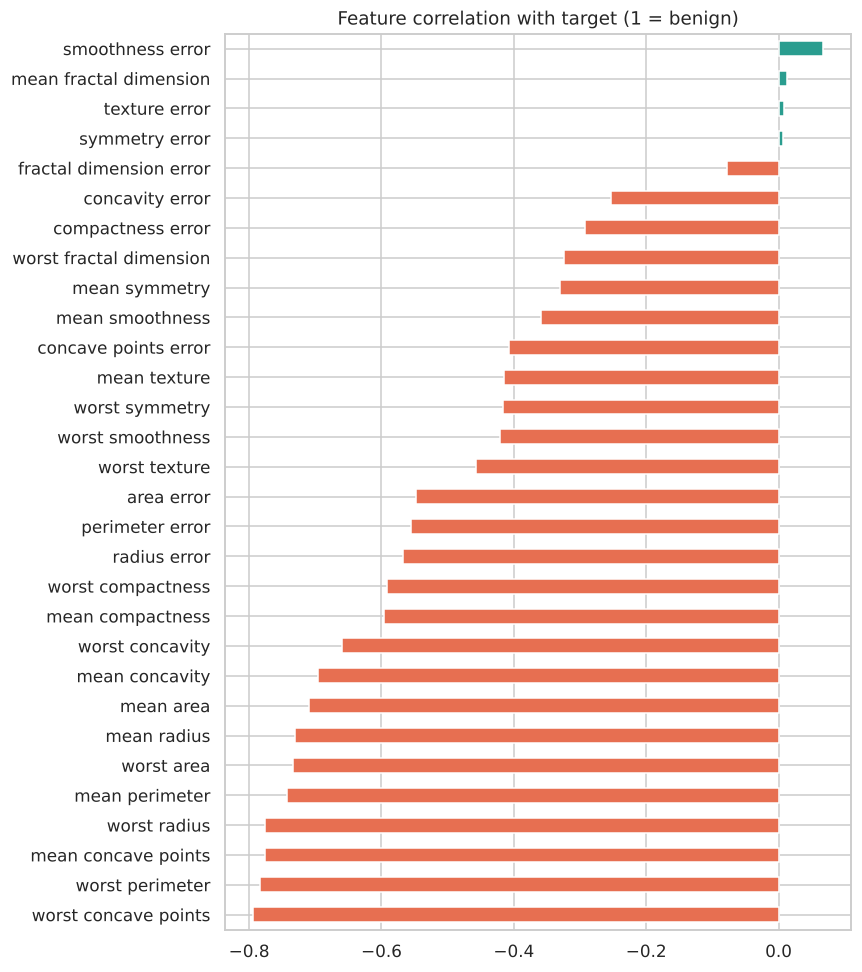

In [4]:
# Correlation of every feature with the target (sorted)
corr = df.drop(columns="diagnosis").corr()["target"].drop("target").sort_values()

plt.figure(figsize=(8, 9))
corr.plot(kind="barh", color=np.where(corr < 0, "#e76f51", "#2a9d8f"))
plt.title("Feature correlation with target (1 = benign)")
plt.tight_layout()
plt.savefig("images/02_feature_correlation.png", dpi=130)
plt.show()

**Observations**
- The classes are moderately imbalanced (about 63% benign / 37% malignant), so I use **stratified** splits and report precision, recall, F1 and ROC-AUC alongside accuracy.
- Size and shape features (radius, perimeter, area, concavity) are strongly correlated with the diagnosis.
- There are no missing values or duplicates, so the main preprocessing step is **feature scaling**.

## 3. Preprocessing and train/test split
- 80/20 **stratified** split so both sets keep the same class ratio.
- `StandardScaler` is placed **inside a Pipeline**, so it is fitted only on training folds. This prevents data leakage during cross-validation.

In [5]:
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train class ratio (benign):", round(y_train.mean(), 3), "| Test:", round(y_test.mean(), 3))

Train: (455, 30) | Test: (114, 30)
Train class ratio (benign): 0.626 | Test: 0.632


## 4. Compare algorithms with 5-fold cross-validation

In [6]:
models = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()),
                                     ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    "Random Forest": Pipeline([("scaler", StandardScaler()),
                               ("clf", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))]),
    "Gradient Boosting": Pipeline([("scaler", StandardScaler()),
                                   ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_rows = []
for name, model in models.items():
    res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    row = {"Model": name}
    for m in scoring:
        row[m] = f"{res['test_' + m].mean():.3f} +/- {res['test_' + m].std():.3f}"
    cv_rows.append(row)

cv_table = pd.DataFrame(cv_rows).set_index("Model")
cv_table

,accuracy,precision,recall,f1,roc_auc
Model,,,,,
Logistic Regression,0.978 +/- 0.010,0.979 +/- 0.016,0.986 +/- 0.013,0.983 +/- 0.008,0.996 +/- 0.005
Random Forest,0.965 +/- 0.018,0.976 +/- 0.020,0.968 +/- 0.026,0.972 +/- 0.014,0.990 +/- 0.007
Gradient Boosting,0.952 +/- 0.015,0.962 +/- 0.016,0.961 +/- 0.020,0.961 +/- 0.012,0.992 +/- 0.005


## 5. Hyper-parameter tuning
All three models score closely, so I tune the **Random Forest** and **Logistic Regression** with `GridSearchCV` (optimising ROC-AUC) and keep whichever generalises best in cross-validation.

In [7]:
grids = {
    "Logistic Regression (tuned)": (
        models["Logistic Regression"],
        {"clf__C": [0.01, 0.1, 1, 10, 100]},
    ),
    "Random Forest (tuned)": (
        models["Random Forest"],
        {"clf__n_estimators": [200, 400],
         "clf__max_depth": [None, 5, 10],
         "clf__min_samples_leaf": [1, 2, 4]},
    ),
}

tuned = {}
for name, (pipe, grid) in grids.items():
    gs = GridSearchCV(pipe, grid, cv=cv, scoring="roc_auc", n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned[name] = gs
    print(f"{name}: best CV ROC-AUC = {gs.best_score_:.4f} | best params = {gs.best_params_}")

Logistic Regression (tuned): best CV ROC-AUC = 0.9959 | best params = {'clf__C': 1}
Random Forest (tuned): best CV ROC-AUC = 0.9908 | best params = {'clf__max_depth': 5, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 200}


## 6. Final evaluation on the held-out test set

In [8]:
final_models = {
    "Logistic Regression": models["Logistic Regression"],
    "Random Forest": models["Random Forest"],
    "Gradient Boosting": models["Gradient Boosting"],
    "Logistic Regression (tuned)": tuned["Logistic Regression (tuned)"].best_estimator_,
    "Random Forest (tuned)": tuned["Random Forest (tuned)"].best_estimator_,
}

rows, fitted = [], {}
for name, model in final_models.items():
    model.fit(X_train, y_train)
    fitted[name] = model
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })

results = pd.DataFrame(rows).set_index("Model").round(4)
results.to_csv("results_test_metrics.csv")
results

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9954
Random Forest,0.9474,0.9583,0.9583,0.9583,0.9937
Gradient Boosting,0.9561,0.9467,0.9861,0.9660,0.9907
Logistic Regression (tuned),0.9825,0.9861,0.9861,0.9861,0.9954
Random Forest (tuned),0.9561,0.9589,0.9722,0.9655,0.9934


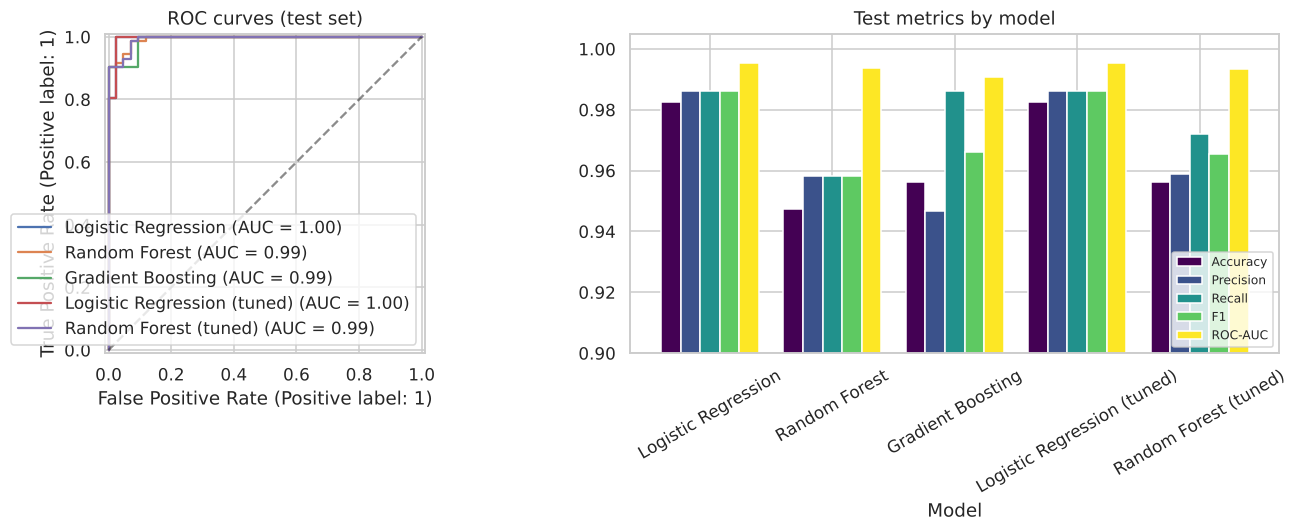

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curves
for name, model in fitted.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set_title("ROC curves (test set)")

# Metric comparison
results.plot(kind="bar", ax=axes[1], colormap="viridis", width=0.8)
axes[1].set_ylim(0.90, 1.005)
axes[1].set_title("Test metrics by model")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig("images/03_roc_and_metrics.png", dpi=130)
plt.show()

Best model: Logistic Regression

              precision    recall  f1-score   support

   malignant      0.976     0.976     0.976        42
      benign      0.986     0.986     0.986        72

    accuracy                          0.982       114
   macro avg      0.981     0.981     0.981       114
weighted avg      0.982     0.982     0.982       114


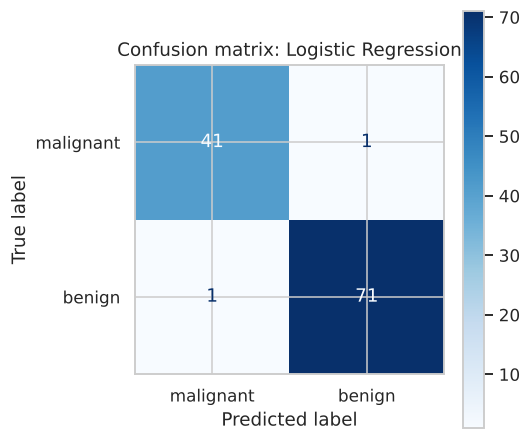

In [10]:
# Pick the best model by F1, with ROC-AUC as tie-breaker
best_name = results.sort_values(["F1", "ROC-AUC"], ascending=False).index[0]
best_model = fitted[best_name]
print("Best model:", best_name)

pred = best_model.predict(X_test)
print()
print(classification_report(y_test, pred, target_names=["malignant", "benign"], digits=3))

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["malignant", "benign"],
                                        cmap="Blues", ax=ax)
ax.set_title(f"Confusion matrix: {best_name}")
plt.tight_layout()
plt.savefig("images/04_confusion_matrix.png", dpi=130)
plt.show()

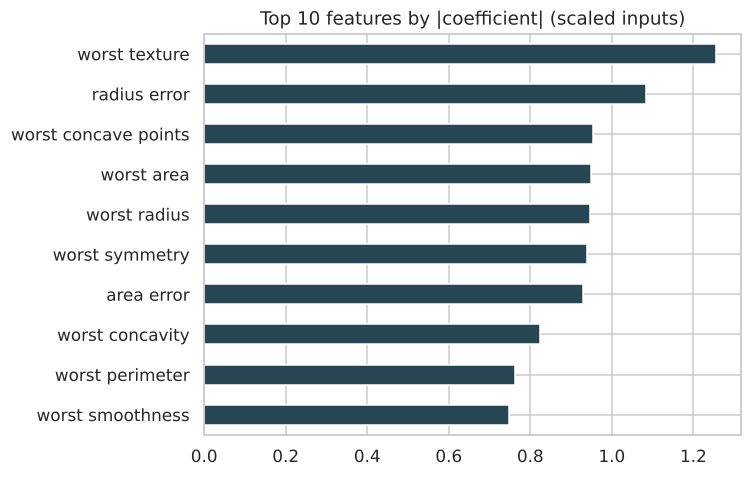

In [11]:
# Which features matter most in the final model?
clf = best_model.named_steps["clf"]
if hasattr(clf, "feature_importances_"):
    importances = pd.Series(clf.feature_importances_, index=X.columns)
    title = "Top 10 feature importances"
else:
    importances = pd.Series(np.abs(clf.coef_[0]), index=X.columns)
    title = "Top 10 features by |coefficient| (scaled inputs)"

top = importances.sort_values(ascending=False).head(10)[::-1]
plt.figure(figsize=(7, 4.5))
top.plot(kind="barh", color="#264653")
plt.title(title)
plt.tight_layout()
plt.savefig("images/05_feature_importance.png", dpi=130)
plt.show()

## 7. Conclusion
- All models performed strongly (see the table in section 6). I selected the final model by **F1 on the held-out test set**, with ROC-AUC as the tie-breaker.
- In a medical screening setting, **recall for the malignant class** matters most, since a false negative (a missed cancer) is costlier than a false positive. The confusion matrix shows how many malignant cases were missed.
- Cross-validation standard deviations are small, so the results are stable across folds.
- **Limitations:** the dataset is small (569 rows) and one test split can be noisy; a real deployment would need external validation.
- **Next steps:** calibrate probabilities, explore threshold tuning to favour recall, and add model interpretation with SHAP (Task 4).